# Phase 1 & 3: Exploratory Data Analysis (EDA) & Feature Engineering
## S&P 500 Machine Learning Trading Model

This notebook focuses on:
1. Downloading daily historical data for SPY (S&P 500 ETF) using `yfinance` (with synthetic fallback).
2. Calculating technical indicators (RSI, MACD, Bollinger Bands, Moving Average Ratios, Volatility).
3. Applying **strict 1-day feature lagging (`shift(1)`)** to eliminate look-ahead bias.
4. Constructing discretized 5-day future return target labels (Buy `1`, Sell `-1`, Hold `0`).
5. Analyzing class balance, feature distributions, and correlation heatmaps.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


### Step 1: Data Acquisition

In [2]:
def load_sp500_data():
    try:
        import yfinance as yf
        print("Downloading SPY data from yfinance...")
        df = yf.download("SPY", start="2010-01-01", end="2024-01-01", progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
    except Exception as e:
        print(f"yfinance download failed or unavailable ({e}). Generating synthetic SPY prices for demonstration...")
        dates = pd.date_range(start="2010-01-01", end="2024-01-01", freq="B")
        np.random.seed(42)
        returns = np.random.normal(0.0004, 0.01, len(dates))
        price = 100 * np.exp(np.cumsum(returns))
        df = pd.DataFrame({
            'Open': price * (1 + np.random.normal(0, 0.002, len(dates))),
            'High': price * (1 + abs(np.random.normal(0, 0.005, len(dates)))),
            'Low': price * (1 - abs(np.random.normal(0, 0.005, len(dates)))),
            'Close': price,
            'Volume': np.random.randint(1000000, 5000000, len(dates))
        }, index=dates)
    return df

raw_df = load_sp500_data()
print(f"Dataset loaded: {len(raw_df)} trading days from {raw_df.index.min().date()} to {raw_df.index.max().date()}")
raw_df.head()

Dataset loaded: 3522 trading days from 2010-01-04 to 2023-12-29


Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,83.654313,84.413653,83.014082,84.368988,118944600
2010-01-05,84.316856,84.629525,84.011627,84.592300,111579900
2010-01-06,84.510423,84.860317,84.443424,84.651871,116074400
2010-01-07,84.495541,85.113439,84.257316,85.009216,131091100
2010-01-08,84.785855,85.329309,84.614634,85.292084,126402800


### Step 2: Feature Engineering & Strict Feature Lagging

In [3]:
def engineer_features_and_target(df, buy_thresh=0.01, sell_thresh=-0.01):
    data = df.copy()
    
    # 1. Stationary Returns
    data['daily_return'] = data['Close'].pct_change(1)
    data['return_5d'] = data['Close'].pct_change(5)
    
    # 2. Moving Averages
    data['sma_20'] = data['Close'].rolling(20).mean()
    data['sma_50'] = data['Close'].rolling(50).mean()
    data['sma_ratio'] = data['sma_20'] / data['sma_50']
    
    # 3. RSI (14-period)
    delta = data['Close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-8)
    data['rsi_14'] = 100 - (100 / (1 + rs))
    
    # 4. MACD
    ema12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema26 = data['Close'].ewm(span=26, adjust=False).mean()
    data['macd'] = ema12 - ema26
    data['macd_signal'] = data['macd'].ewm(span=9, adjust=False).mean()
    
    # 5. Bollinger Bands & Volatility
    bb_mid = data['Close'].rolling(20).mean()
    bb_std = data['Close'].rolling(20).std()
    data['bb_width'] = (2 * bb_std) / bb_mid
    data['volatility_20d'] = data['daily_return'].rolling(20).std()
    
    # Unlagged feature list
    feature_cols = ['daily_return', 'return_5d', 'sma_ratio', 'rsi_14', 'macd', 'macd_signal', 'bb_width', 'volatility_20d']
    
    # STRICT 1-DAY FEATURE LAGGING (shift by 1 day to prevent look-ahead bias)
    lagged_features = data[feature_cols].shift(1)
    lagged_cols = [f"{col}_lag1" for col in feature_cols]
    lagged_features.columns = lagged_cols
    
    # Target Construction (5-day Future Return Discretization)
    future_return_5d = data['Close'].shift(-5) / data['Close'] - 1.0
    conditions = [
        future_return_5d > buy_thresh,
        future_return_5d < sell_thresh
    ]
    choices = [1, -1] # 1: Buy, -1: Sell, 0: Hold
    data['target'] = np.select(conditions, choices, default=0)
    
    # Combine into clean dataframe
    clean_df = pd.concat([data[['Close', 'target']], lagged_features], axis=1).dropna()
    return clean_df, lagged_cols

df_ml, feature_cols = engineer_features_and_target(raw_df)
print(f"Engineered dataset shape: {df_ml.shape}")
df_ml.head()

Engineered dataset shape: (3472, 10)


,Close,target,daily_return_lag1,return_5d_lag1,sma_ratio_lag1,rsi_14_lag1,macd_lag1,macd_signal_lag1,bb_width_lag1,volatility_20d_lag1
Date,,,,,,,,,,
2010-03-17,87.175575,0,0.007966,0.017037,1.010541,97.453736,1.094204,0.766343,0.037435,0.005395
2010-03-18,87.130905,0,0.005927,0.018526,1.012921,99.999997,1.182258,0.849526,0.039502,0.005422
2010-03-19,86.689903,0,-0.000512,0.013772,1.015046,99.065359,1.234210,0.926462,0.041175,0.005433
2010-03-22,87.153336,0,-0.005061,0.008554,1.016923,88.871657,1.225668,0.986304,0.041597,0.005704
2010-03-23,87.766273,0,0.005346,0.013682,1.019041,89.434863,1.241977,1.037438,0.042150,0.005718


### Step 3: Class Distribution Analysis

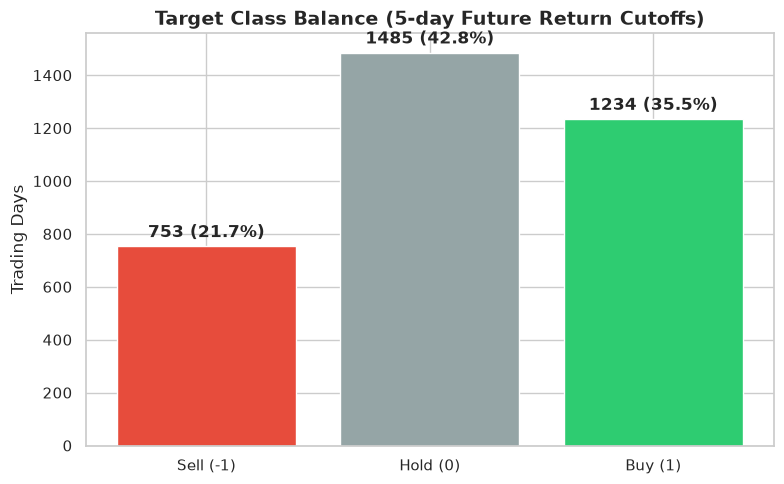

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
class_counts = df_ml['target'].value_counts().sort_index()
class_labels = { -1: 'Sell (-1)', 0: 'Hold (0)', 1: 'Buy (1)' }
x_labels = [class_labels[i] for i in class_counts.index]

bars = ax.bar(x_labels, class_counts.values, color=['#e74c3c', '#95a5a6', '#2ecc71'])
ax.set_title('Target Class Balance (5-day Future Return Cutoffs)', fontsize=14, fontweight='bold')
ax.set_ylabel('Trading Days')

for bar in bars:
    yval = bar.get_height()
    pct = yval / len(df_ml) * 100
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 20, f'{yval} ({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Step 4: Feature Correlations with Target

/tmp/ipykernel_6588/1467787425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, ax=ax, palette='Blues_r')


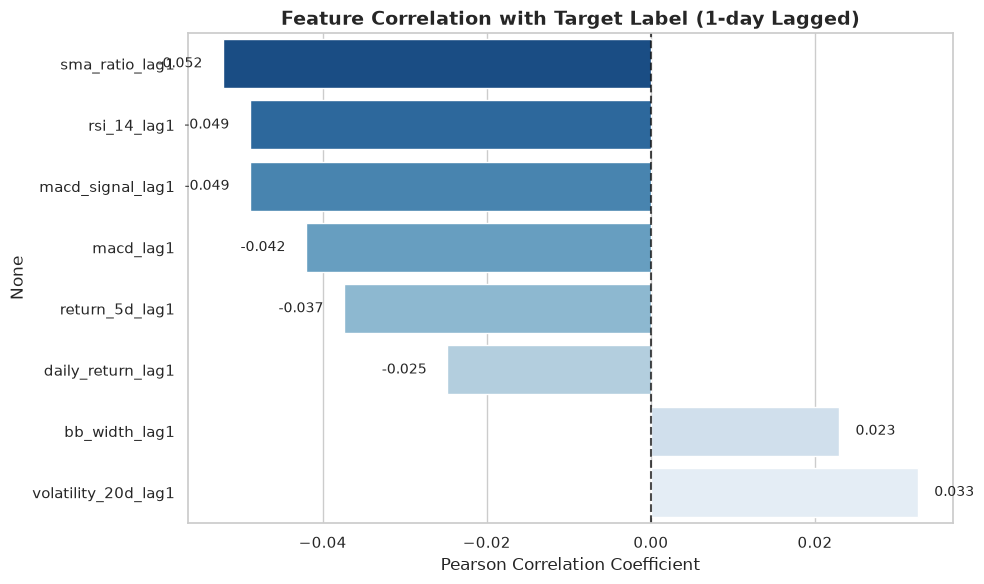

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
corr = df_ml[feature_cols + ['target']].corr()['target'].drop('target').sort_values()

sns.barplot(x=corr.values, y=corr.index, ax=ax, palette='Blues_r')
ax.set_title('Feature Correlation with Target Label (1-day Lagged)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.axvline(0, color='black', linestyle='--', alpha=0.7)

for i, v in enumerate(corr.values):
    ax.text(v + (0.002 if v >= 0 else -0.008), i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()